# Week 1 Capstone Review

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

This notebook loads and validates the eight Week 1 black-box optimisation datasets, reports each function separately, and then compares the recorded search strategies. It is safe to run from the repository root, the notebook folder, or another subfolder of the repository.

<a id="objectives"></a>
## 2. Objectives

Validate all eight starter datasets, review each function independently, compare recorded strategies descriptively, and preserve a reproducible baseline for later optimisation rounds.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

- The original `initial_data_1/function_n` path did not exist in this repository. Data actually lives in `Week_01/Function_nn/03_Data`.
- Repeated loading code was replaced with validated helper functions.
- Input/output row counts, dimensionality, numeric types, finite values, and the expected `[0, 1]` input domain are checked before analysis.
- Empty cells and duplicate directory-listing cells were removed.
- Strategy averages are labelled as descriptive only: objective values from different black-box functions have different scales and must not be used to rank optimisation techniques directly.
- Matplotlib is used to render query history, running-best progress, and every input/output relationship for all eight functions.

<a id="environment-setup"></a>
## 4. Environment and setup

Locate the repository, define dimensions and strategies, and initialise reusable loading and summary helpers.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

FUNCTION_NUMBERS = tuple(range(1, 9))
EXPECTED_DIMENSIONS = {1: 2, 2: 2, 3: 3, 4: 4, 5: 4, 6: 5, 7: 6, 8: 8}
STRATEGY = {
    1: 'Random Search', 2: 'Random Search',
    3: 'Grid Search', 4: 'Grid Search',
    5: 'Manual Reasoning', 6: 'Manual Reasoning',
    7: 'Bayesian Optimisation', 8: 'Bayesian Optimisation',
}

def find_repository_root(start=None):
    """Find the repository containing the Week_01 data folder."""
    current = Path.cwd() if start is None else Path(start).expanduser().resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'Week_01').is_dir():
            return candidate
    raise FileNotFoundError('Could not find a parent directory containing Week_01.')

REPO_ROOT = find_repository_root()
WEEK_ROOT = REPO_ROOT / 'Week_01'
print(f'Repository root: {REPO_ROOT}')

Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def function_data_files(function_number):
    """Return the input and output files for one Week 1 function."""
    if function_number not in FUNCTION_NUMBERS:
        raise ValueError(f'function_number must be 1..8, got {function_number!r}')
    data_dir = WEEK_ROOT / f'Function_{function_number:02d}' / '03_Data'
    input_file = data_dir / 'initial_inputs.npy'
    output_file = data_dir / 'initial_outputs.npy'
    missing = [str(path) for path in (input_file, output_file) if not path.is_file()]
    if missing:
        raise FileNotFoundError('Missing Week 1 data file(s): ' + ', '.join(missing))
    return input_file, output_file

def load_function_data(function_number):
    """Load and validate one function's observations."""
    input_file, output_file = function_data_files(function_number)
    X = np.asarray(np.load(input_file), dtype=float)
    y = np.asarray(np.load(output_file), dtype=float).reshape(-1)
    expected_dimension = EXPECTED_DIMENSIONS[function_number]
    if X.ndim != 2 or X.shape[1] != expected_dimension:
        raise ValueError(f'F{function_number}: expected a 2-D input array with {expected_dimension} columns; got {X.shape}.')
    if X.shape[0] != y.size or y.size == 0:
        raise ValueError(f'F{function_number}: input rows ({X.shape[0]}) and outputs ({y.size}) must match and be non-empty.')
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(f'F{function_number}: inputs and outputs must contain only finite values.')
    if np.any((X < 0.0) | (X > 1.0)):
        raise ValueError(f'F{function_number}: input values must lie in [0, 1].')
    return X, y

In [3]:
def summarize_function(function_number):
    """Return a validated summary for one objective function."""
    X, y = load_function_data(function_number)
    best_index = int(np.argmax(y))
    return {
        'Function': f'F{function_number}',
        'Strategy': STRATEGY[function_number],
        'Observations': int(y.size),
        'Dimensions': int(X.shape[1]),
        'Minimum output': float(np.min(y)),
        'Mean output': float(np.mean(y)),
        'Maximum output': float(y[best_index]),
        'Best query': best_index + 1,
        'Best input': X[best_index].tolist(),
    }

function_summaries = pd.DataFrame([summarize_function(i) for i in FUNCTION_NUMBERS])
function_summaries

,Function,Strategy,Observations,Dimensions,Minimum output,Mean output,Maximum output,Best query,Best input
0,F1,Random Search,10,2,-0.003606,-0.000361,7.710875e-16,3,"[0.7310236309563586, 0.7329998764152272]"
1,F2,Random Search,10,2,-0.065624,0.230674,6.112052e-01,10,"[0.7026365569244406, 0.9265641975455574]"
2,F3,Grid Search,15,3,-0.398926,-0.107167,-3.483531e-02,4,"[0.49258141463713434, 0.6115931882759961, 0.34..."
3,F4,Grid Search,30,4,-32.625660,-17.238587,-4.025542e+00,28,"[0.5777656143780968, 0.4287717415443063, 0.425..."
4,F5,Manual Reasoning,20,4,0.112940,151.271876,1.088860e+03,16,"[0.22418902330288348, 0.8464804904862864, 0.87..."
5,F6,Manual Reasoning,20,5,-2.571170,-1.495390,-7.142649e-01,1,"[0.7281861047460138, 0.1546925696237983, 0.732..."
6,F7,Bayesian Optimisation,30,6,0.002701,0.219607,1.364968e+00,7,"[0.057895541971385245, 0.49167221863901367, 0...."
7,F8,Bayesian Optimisation,40,8,5.592193,7.815274,9.598482e+00,15,"[0.056447411065611686, 0.06595555344270987, 0...."


<a id="data-validation"></a>
## 5. Data validation

Validate shape, dimensionality, bounds, finiteness, and input/output alignment for every starter dataset.

<a id="descriptive-eda"></a>
## 6. Descriptive EDA

Each row below is independently validated. Negative maxima in F3, F4, and F6 are valid: the task is to maximise each unknown function, so the least-negative observed value is the best observation for those functions.

In [4]:
for function_number in FUNCTION_NUMBERS:
    summary = summarize_function(function_number)
    print(f"{summary['Function']}: {summary['Observations']} observations, "
          f"{summary['Dimensions']} dimensions, strategy={summary['Strategy']}")
    print(f"  best query={summary['Best query']}, maximum={summary['Maximum output']:.12g}")
    print(f"  best input={np.array(summary['Best input'])}")

F1: 10 observations, 2 dimensions, strategy=Random Search
  best query=3, maximum=7.7108751145e-16
  best input=[0.73102363 0.73299988]
F2: 10 observations, 2 dimensions, strategy=Random Search
  best query=10, maximum=0.611205215761
  best input=[0.70263656 0.9265642 ]
F3: 15 observations, 3 dimensions, strategy=Grid Search
  best query=4, maximum=-0.0348353133501
  best input=[0.49258141 0.61159319 0.34017639]
F4: 30 observations, 4 dimensions, strategy=Grid Search
  best query=28, maximum=-4.02554228191
  best input=[0.57776561 0.42877174 0.42582587 0.24900741]
F5: 20 observations, 4 dimensions, strategy=Manual Reasoning
  best query=16, maximum=1088.8596182
  best input=[0.22418902 0.84648049 0.87948418 0.87851568]
F6: 20 observations, 5 dimensions, strategy=Manual Reasoning
  best query=1, maximum=-0.71426494782
  best input=[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
F7: 30 observations, 6 dimensions, strategy=Bayesian Optimisation
  best query=7, maximum=1.364968304

This table reproduces the original grouping, but its cross-function mean is **not a fair performance comparison**. In particular, F5's output scale is orders of magnitude larger than the others, so it dominates the Manual Reasoning mean. A valid technique comparison would require applying each technique to the same functions and comparing normalised improvement or regret under equal budgets.

In [5]:
strategy_summary = (
    function_summaries.groupby('Strategy', sort=False)
    .agg(Functions=('Function', lambda values: ', '.join(values)),
         Function_count=('Function', 'size'),
         Descriptive_mean_of_maxima=('Maximum output', 'mean'))
    .reset_index()
)
strategy_summary

,Strategy,Functions,Function_count,Descriptive_mean_of_maxima
0,Random Search,"F1, F2",2,0.305603
1,Grid Search,"F3, F4",2,-2.030189
2,Manual Reasoning,"F5, F6",2,544.072677
3,Bayesian Optimisation,"F7, F8",2,5.481725


<a id="visual-eda"></a>
## 7. Visual EDA

Visualise observations, running-best progress, and feature/output relationships for each function.

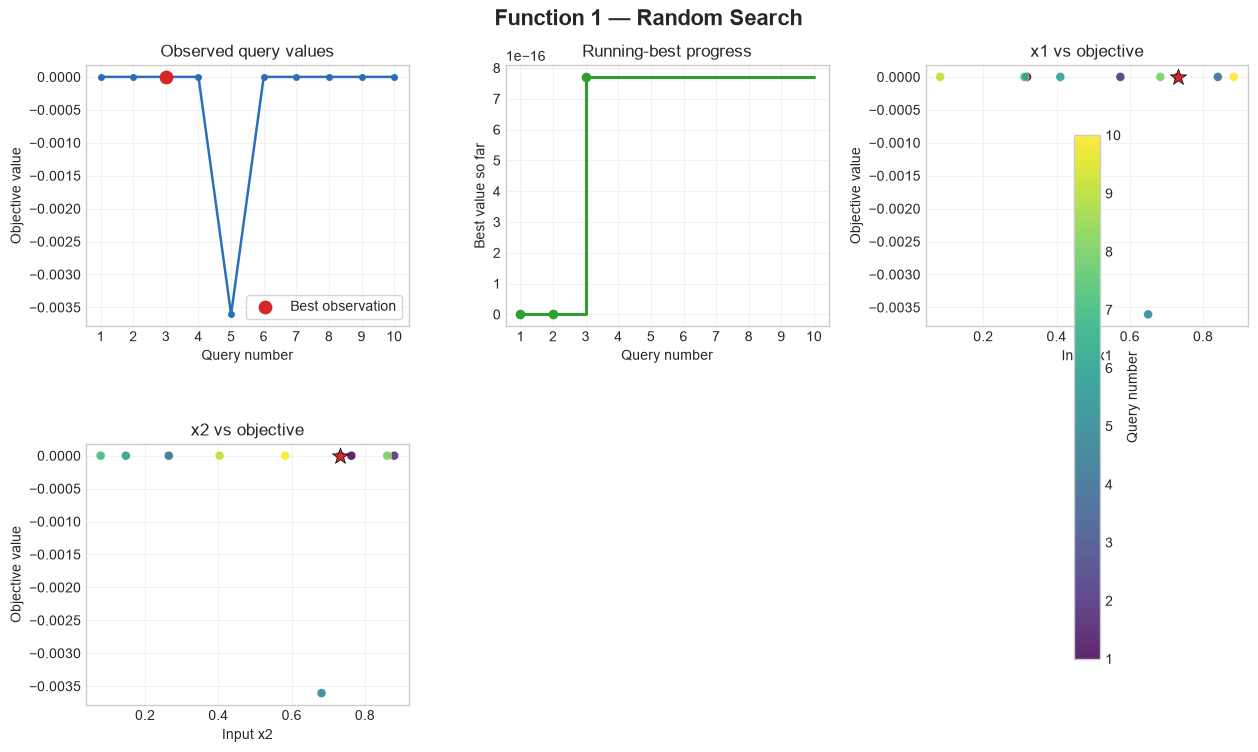

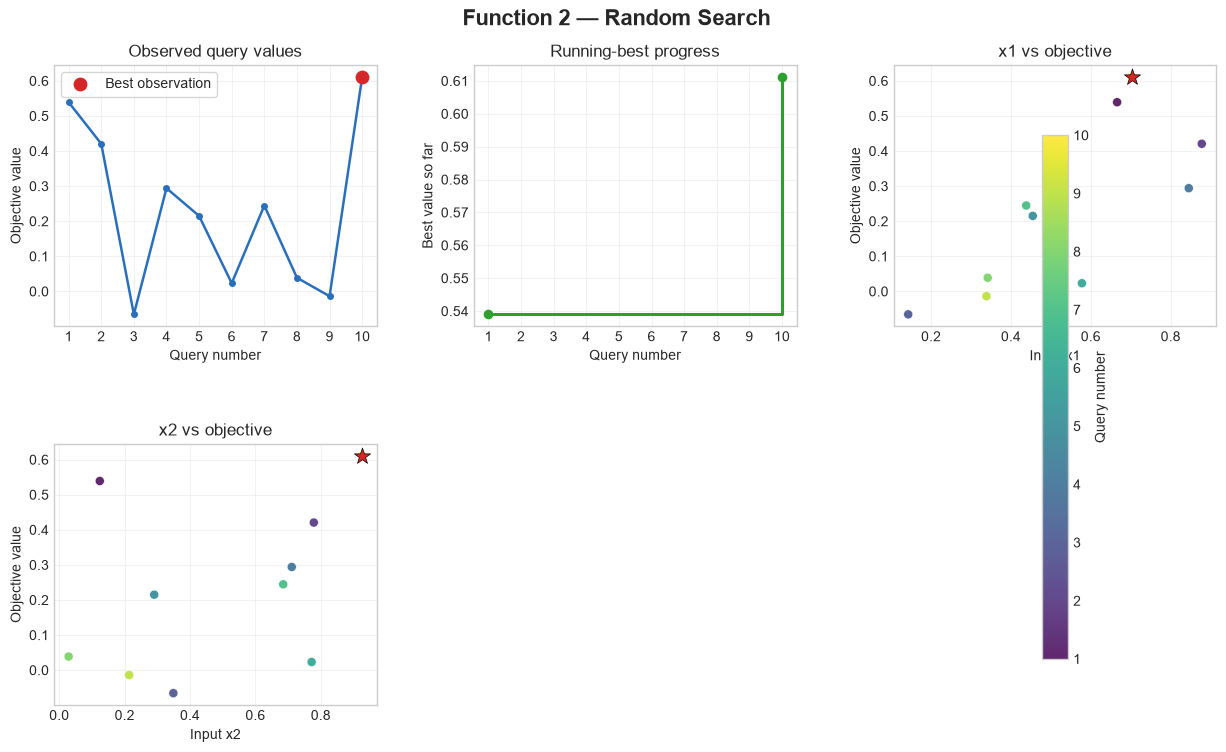

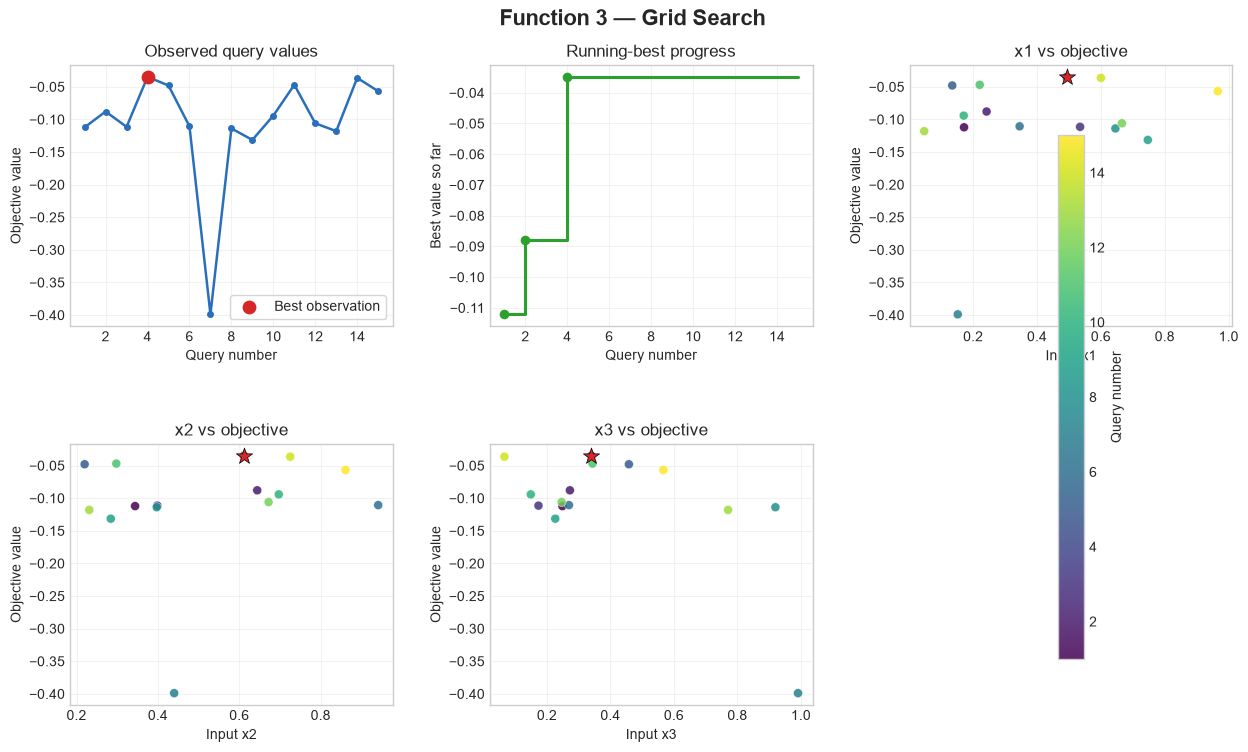

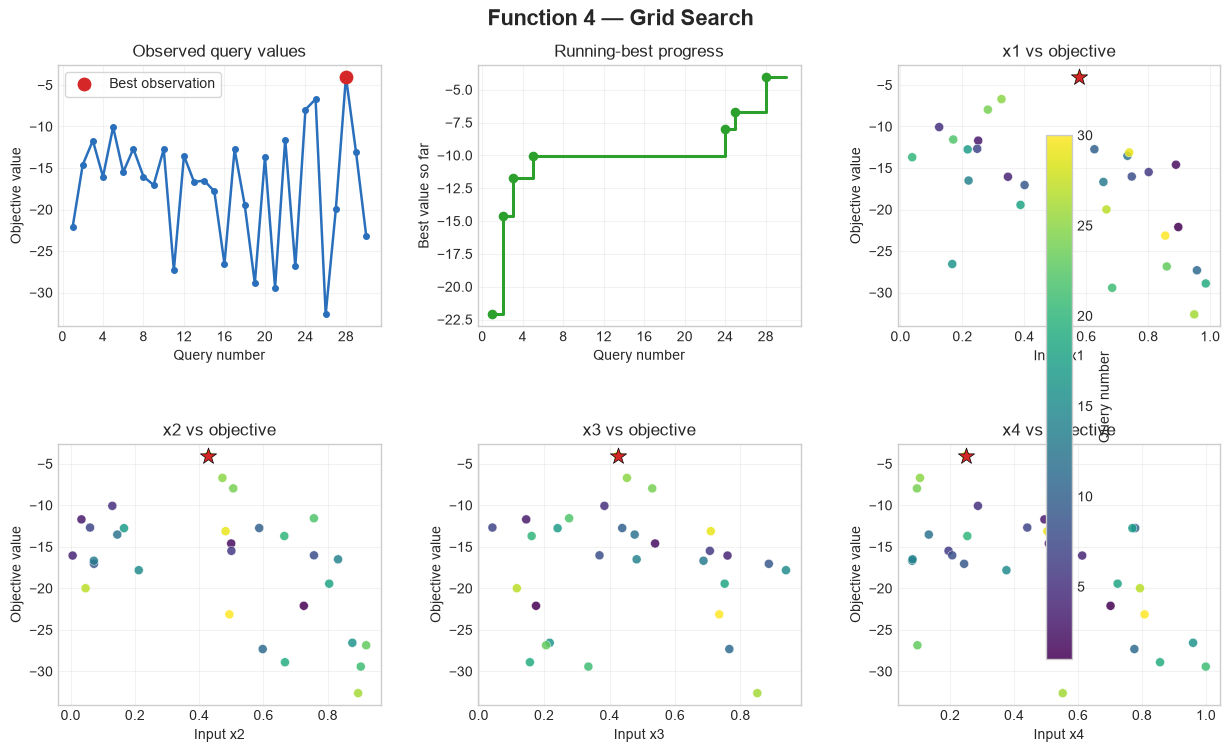

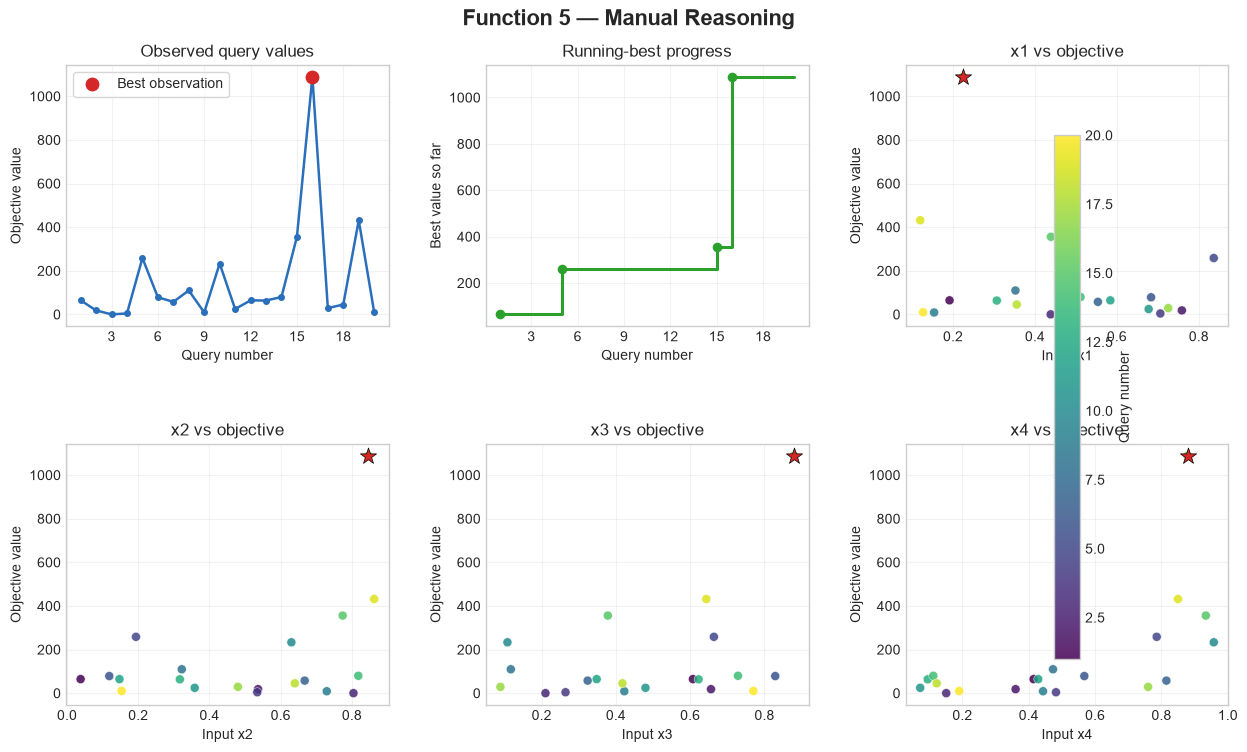

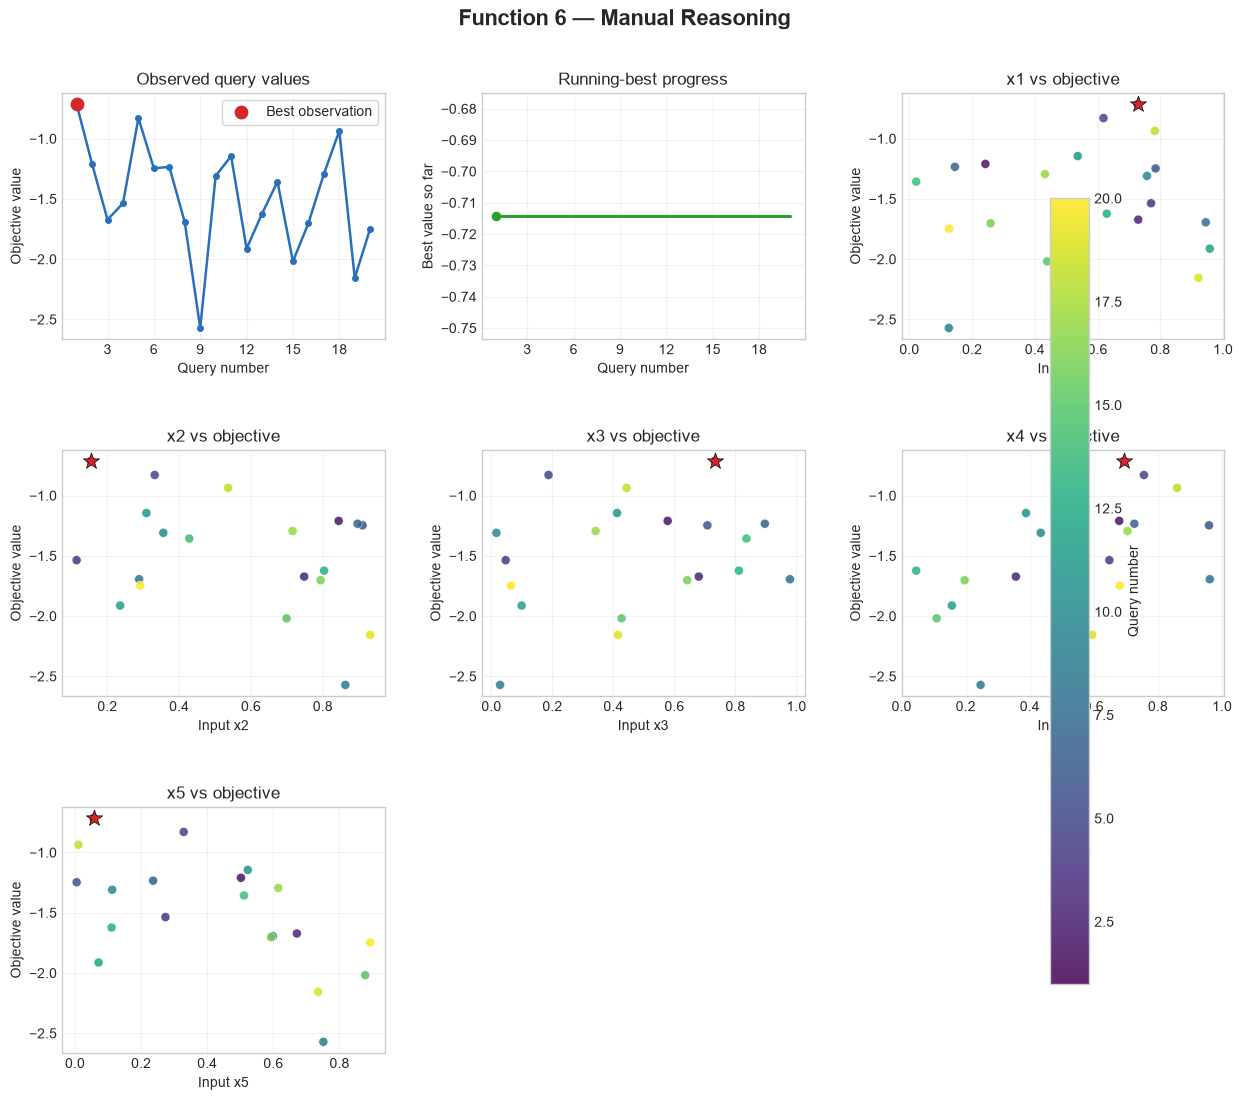

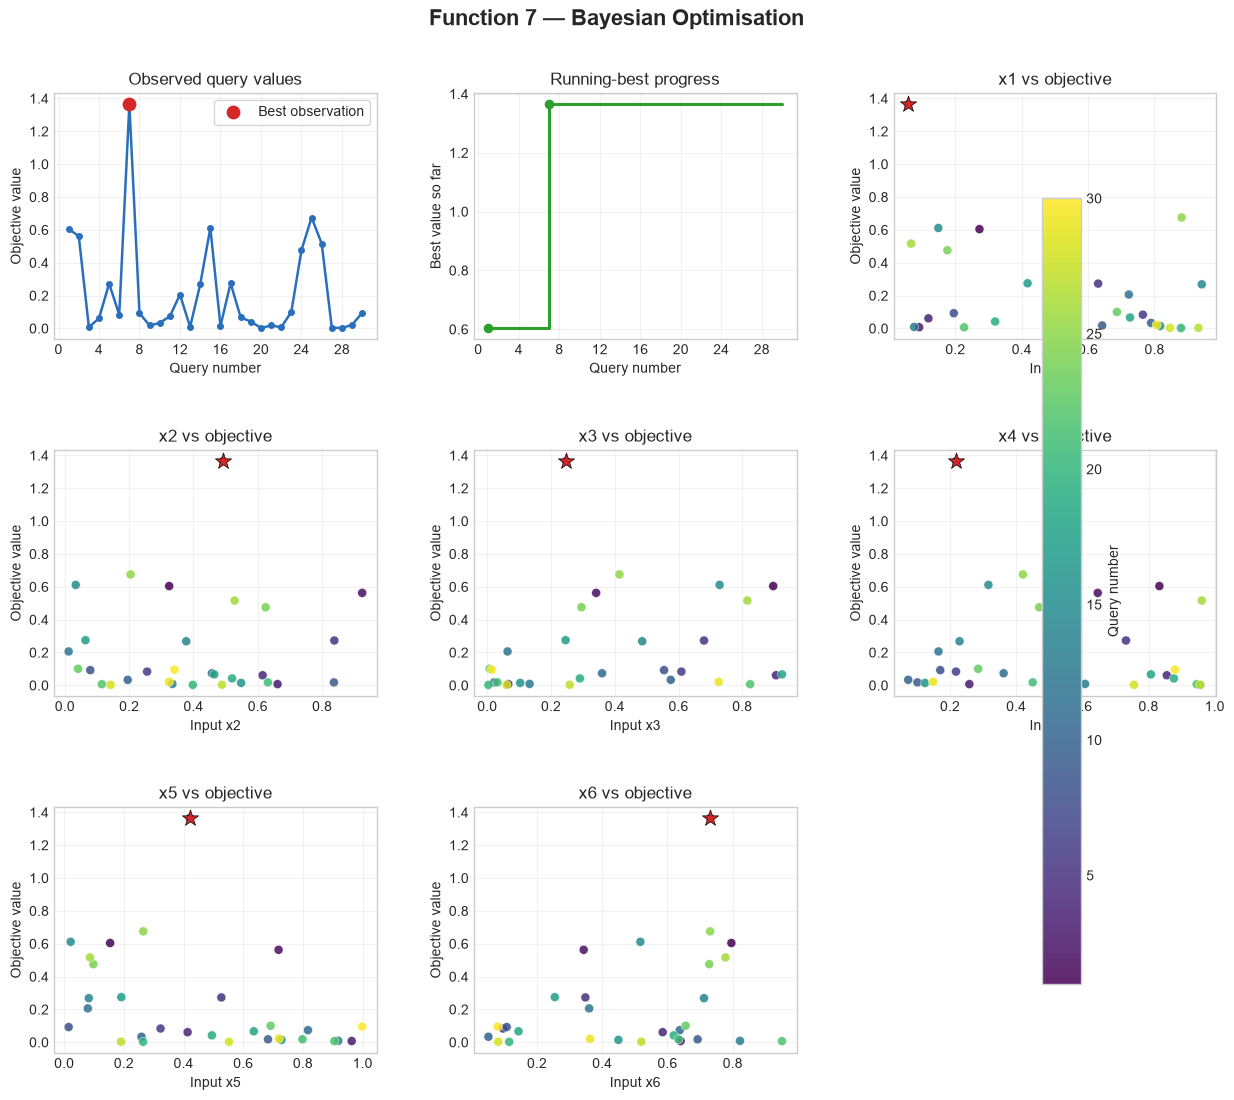

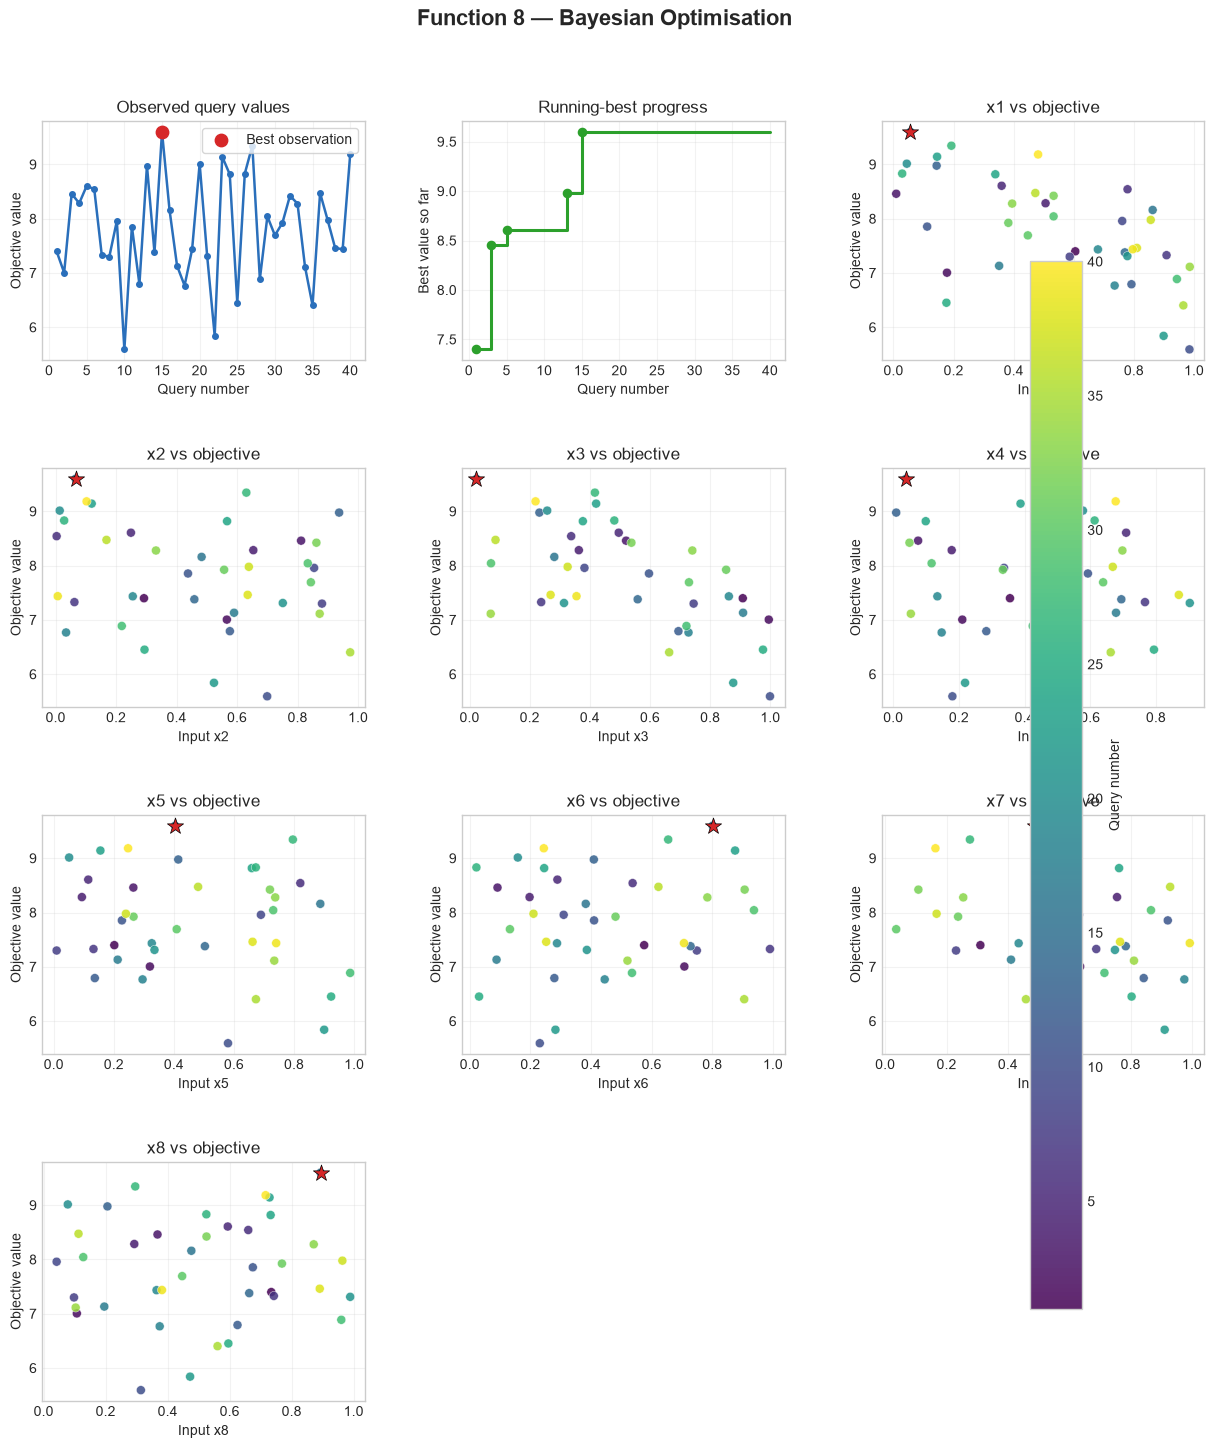

Rendered 8 figures covering all eight functions.


In [6]:
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-whitegrid')

def plot_function(function_number):
    """Plot observations, running best, and every feature relationship."""
    X, y = load_function_data(function_number)
    queries = np.arange(1, y.size + 1)
    best_index = int(np.argmax(y))
    panel_count = X.shape[1] + 2
    columns = 3
    rows = math.ceil(panel_count / columns)
    figure, axes = plt.subplots(rows, columns, figsize=(15, 4 * rows), squeeze=False)
    axes = axes.ravel()

    axes[0].plot(queries, y, color='#2a6fbb', marker='o', linewidth=1.8, markersize=4)
    axes[0].scatter(queries[best_index], y[best_index], color='#d62728', s=80, zorder=3, label='Best observation')
    axes[0].set(xlabel='Query number', ylabel='Objective value', title='Observed query values')
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].legend(frameon=True)

    running_best = np.maximum.accumulate(y)
    axes[1].step(queries, running_best, where='post', color='#2ca02c', linewidth=2.2)
    improvement_queries = np.flatnonzero(np.r_[True, np.diff(running_best) > 0])
    axes[1].scatter(queries[improvement_queries], running_best[improvement_queries], color='#2ca02c', s=35, zorder=3)
    axes[1].set(xlabel='Query number', ylabel='Best value so far', title='Running-best progress')
    axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

    colour_scale = None
    for column, axis in enumerate(axes[2:2 + X.shape[1]]):
        colour_scale = axis.scatter(X[:, column], y, c=queries, cmap='viridis', s=42, alpha=0.85, edgecolor='white', linewidth=0.35)
        axis.scatter(X[best_index, column], y[best_index], marker='*', color='#d62728', s=150, edgecolor='black', linewidth=0.5, zorder=3)
        axis.set(xlabel=f'Input x{column + 1}', ylabel='Objective value', title=f'x{column + 1} vs objective')

    for axis in axes[panel_count:]:
        axis.set_visible(False)
    for axis in axes[:panel_count]:
        axis.grid(True, alpha=0.25)
    if colour_scale is not None:
        figure.colorbar(colour_scale, ax=axes[2:2 + X.shape[1]].tolist(), label='Query number', shrink=0.85)
    figure.suptitle(f'Function {function_number} — {STRATEGY[function_number]}', fontsize=16, fontweight='bold')
    figure.subplots_adjust(top=0.91, hspace=0.45, wspace=0.30)
    return figure

figures = [plot_function(function_number) for function_number in FUNCTION_NUMBERS]
plt.show()
print(f'Rendered {len(figures)} figures covering all eight functions.')

<a id="gp-model-configuration"></a>
## 8. GP model configuration

Week 1 establishes the model-free baseline; Gaussian Process configuration is introduced in later rounds.

<a id="gp-ucb-values"></a>
## 9. GP-UCB values

No GP-UCB proposal is claimed for the Week 1 baseline. The observed starter values remain the authoritative evidence.

<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

These assertions protect the data-loading and summary logic from silent shape, path, or best-index errors.

In [7]:
for function_number in FUNCTION_NUMBERS:
    X, y = load_function_data(function_number)
    summary = summarize_function(function_number)
    assert X.shape == (y.size, EXPECTED_DIMENSIONS[function_number])
    assert summary['Observations'] == y.size
    assert summary['Best query'] == int(np.argmax(y)) + 1
    assert np.isclose(summary['Maximum output'], np.max(y))
    assert np.allclose(summary['Best input'], X[np.argmax(y)])

assert len(function_summaries) == 8
assert function_summaries['Observations'].sum() == 175
assert function_summaries['Dimensions'].tolist() == [2, 2, 3, 4, 4, 5, 6, 8]
print('All Week 1 data and summary checks passed.')

All Week 1 data and summary checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

The validated Week 1 datasets and descriptive baselines provide the starting point for subsequent Bayesian optimisation rounds.